# Clasificación de Asteroides Potencialmente Peligrosos.

#Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Libreria utilizada por el desbalanceo de las clases.
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from collections import Counter


## Carga del dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset Parcial/Asteroid_Dataset.csv')

#Mostrar la carga
print('Primeras filas del dataset:')
display(df.head())


Primeras filas del dataset:


/tmp/ipython-input-1092289996.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset Parcial/Asteroid_Dataset.csv')


,spkid,full_name,pha,H,diameter,albedo,diameter_sigma,e,a,q,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,' 1 Ceres',N,3.40,939.4,0.0900,0.2,0.077557,2.767657,2.553006,...,4.613200e-09,6.176900e-08,6.618400e-08,7.355900e-09,1.115900e-11,1.201400e-12,3.686700e-08,9.439100e-09,MBA,0.40633
1,2000002,' 2 Pallas',N,4.20,545.0,0.1010,18.0,0.229972,2.773841,2.135935,...,3.701900e-06,6.412400e-06,9.494400e-06,9.151500e-06,5.054200e-09,4.740800e-10,4.219400e-05,3.749600e-06,MBA,0.36151
2,2000003,' 3 Juno',N,5.33,246.596,0.2140,10.594000000000001,0.256936,2.668285,1.982706,...,3.232100e-06,1.687400e-05,1.795300e-05,8.114300e-06,4.413000e-09,4.463100e-10,3.530500e-05,3.142200e-06,MBA,0.33306
3,2000004,' 4 Vesta',N,3.00,525.4,0.4228,0.2,0.088516,2.362014,2.152938,...,2.207300e-07,3.940500e-07,1.817500e-07,1.335200e-06,1.681800e-09,2.664000e-10,5.480200e-06,1.301000e-06,MBA,0.39592
4,2000005,' 5 Astraea',N,6.90,106.699,0.2740,3.14,0.190913,2.574037,2.082619,...,2.743600e-06,2.926000e-05,3.016900e-05,8.703600e-06,4.902000e-09,5.724700e-10,3.640700e-05,3.618200e-06,MBA,0.51439


# EDA

In [3]:
print("\n--- Resumen rápido ---")
print("Columnas disponibles:", df.columns.tolist())
print('\nInformación del dataset:')
print("shape (filas, columnas):", df.shape)
print("\n--- Información de columnas y tipos ---")
print(df.info())
print('\nDescripción estadística del dataset:')
display(df.describe().T)



--- Resumen rápido ---
Columnas disponibles: ['spkid', 'full_name', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class', 'rms']

Información del dataset:
shape (filas, columnas): (126131, 35)

--- Información de columnas y tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126131 entries, 0 to 126130
Data columns (total 35 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   spkid           126131 non-null  int64  
 1   full_name       126131 non-null  object 
 2   pha             126131 non-null  object 
 3   H               126131 non-null  float64
 4   diameter        126131 non-null  object 
 5   albedo          126131 non-null  float64
 6   diameter_sigma  126131 non-null  object 
 7   e 

,count,mean,std,min,25%,50%,75%,max
spkid,126131.0,2.153700e+06,1.314243e+05,2.000001e+06,2.044636e+06,2.114846e+06,2.240348e+06,2.539759e+06
H,126131.0,1.504839e+01,1.333276e+00,3.000000e+00,1.440000e+01,1.520000e+01,1.590000e+01,2.290000e+01
albedo,126131.0,1.349266e-01,1.124245e-01,1.000000e-03,5.400000e-02,8.100000e-02,2.000000e-01,1.000000e+00
e,126131.0,1.435603e-01,7.367298e-02,3.094994e-04,8.939352e-02,1.377757e-01,1.891010e-01,9.683957e-01
a,126131.0,2.817265e+00,9.789654e-01,6.262100e-01,2.547302e+00,2.754816e+00,3.094052e+00,2.811747e+02
q,126131.0,2.415783e+00,5.148626e-01,8.181996e-02,2.078295e+00,2.376367e+00,2.695307e+00,4.031871e+01
i,126131.0,9.872223e+00,6.469399e+00,2.205988e-02,4.883127e+00,8.974452e+00,1.320378e+01,1.703346e+02
om,126131.0,1.691942e+02,1.025722e+02,4.184155e-04,8.198599e+01,1.598947e+02,2.542603e+02,3.599998e+02
w,126131.0,1.817834e+02,1.035109e+02,1.299944e-04,9.182556e+01,1.833619e+02,2.716616e+02,3.599978e+02
ma,126131.0,1.838644e+02,1.051144e+02,6.028833e-03,9.188041e+01,1.872966e+02,2.760830e+02,3.599980e+02


In [4]:
# Comprobación y conteo de la columna objetivo 'pha'
if 'pha' in df.columns:
    print("\nConteo de clases en 'pha':")
    print(df['pha'].value_counts(dropna=False))
else:
    print("\nNo encontré la columna 'pha'. Columnas disponibles:")
    print(list(df.columns))


Conteo de clases en 'pha':
pha
N    125975
Y       156
Name: count, dtype: int64


In [5]:
# Convertimos posibles strings que representen nulos a NaN reales
df.replace(['?', 'None', 'none', 'NULL', 'null', 'NaN', 'nan', '--', ' '], np.nan, inplace=True)

# Verificamos valores faltantes
print("\nValores faltantes por columna (orden descendente):")
print(df.isnull().sum().sort_values(ascending=False).head(30))


Valores faltantes por columna (orden descendente):
diameter_sigma    96
diameter           3
spkid              0
pha                0
full_name          0
H                  0
albedo             0
e                  0
a                  0
q                  0
i                  0
om                 0
w                  0
ma                 0
ad                 0
n                  0
tp                 0
tp_cal             0
per                0
per_y              0
moid               0
moid_ld            0
sigma_e            0
sigma_a            0
sigma_q            0
sigma_i            0
sigma_om           0
sigma_w            0
sigma_ma           0
sigma_ad           0
dtype: int64


## Visualización del EDA

/tmp/ipython-input-3396446007.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pha', data=df, palette='pastel')


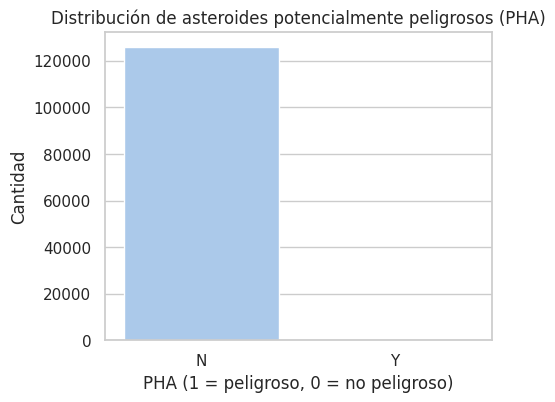

In [6]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# --- Distribución de la variable objetivo ---
if 'pha' in df.columns:
    plt.figure(figsize=(5,4))
    sns.countplot(x='pha', data=df, palette='pastel')
    plt.title("Distribución de asteroides potencialmente peligrosos (PHA)")
    plt.xlabel("PHA (1 = peligroso, 0 = no peligroso)")
    plt.ylabel("Cantidad")
    plt.show()


Total de columnas numéricas: 30


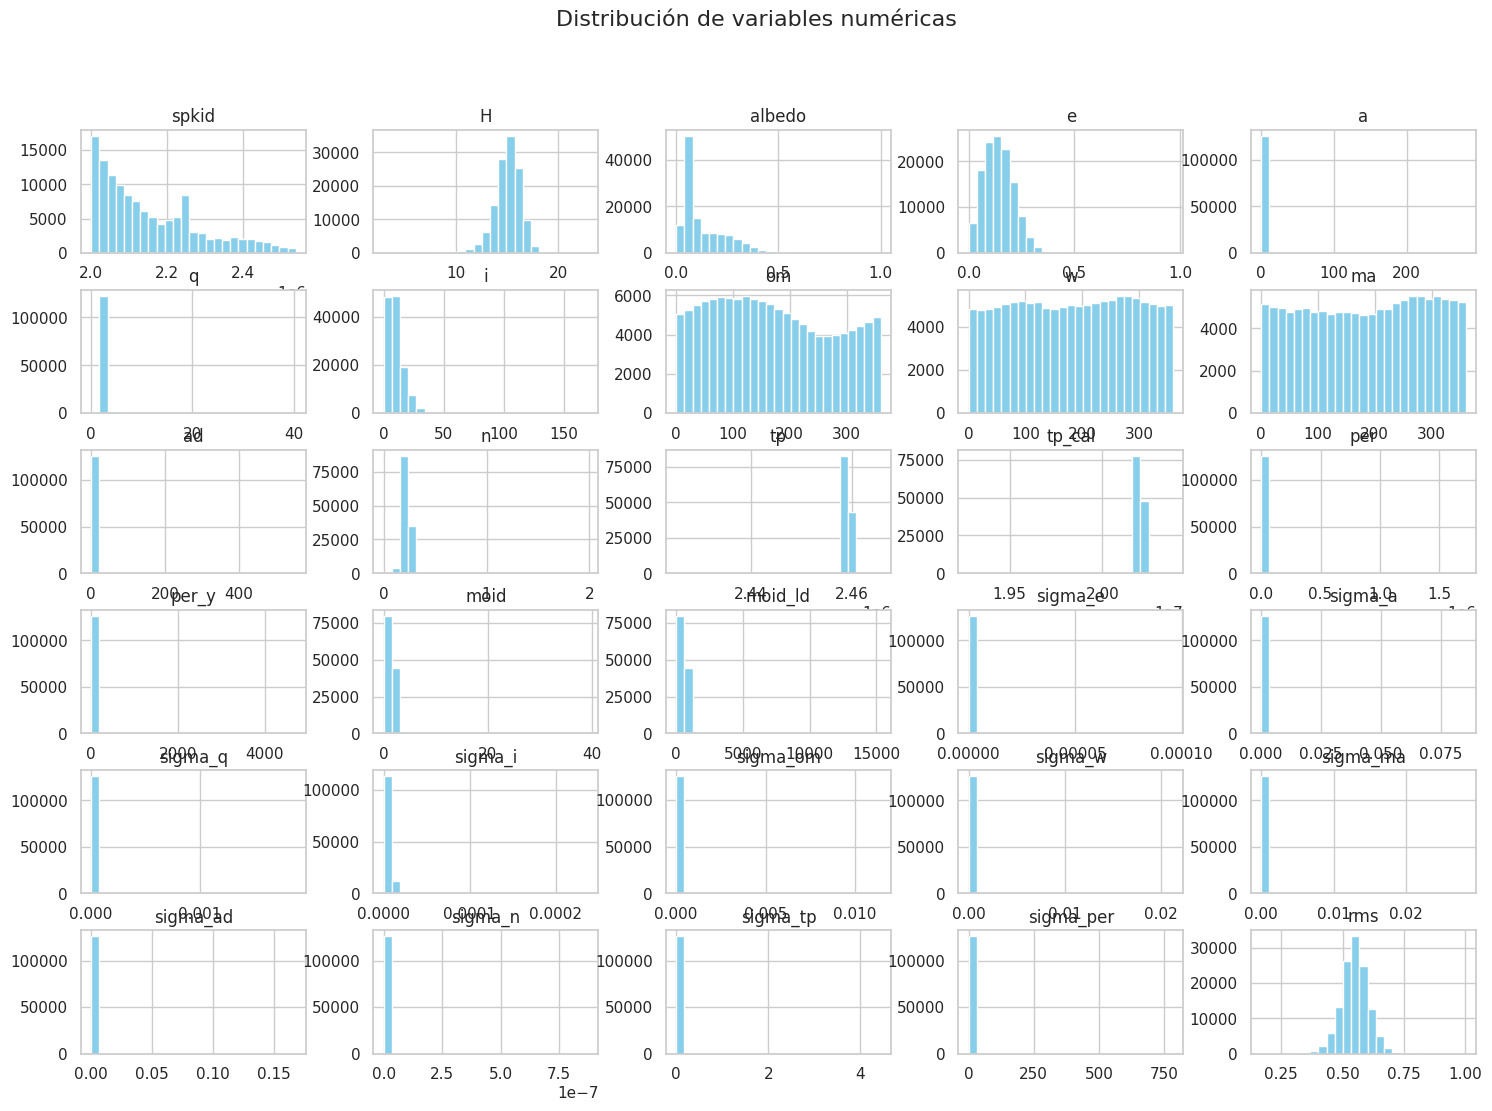

In [7]:
# --- Variables numéricas ---
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(f"\nTotal de columnas numéricas: {len(numeric_cols)}")
# Histogramas generales
df[numeric_cols].hist(bins=25, figsize=(18, 12), color='skyblue')
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.show()

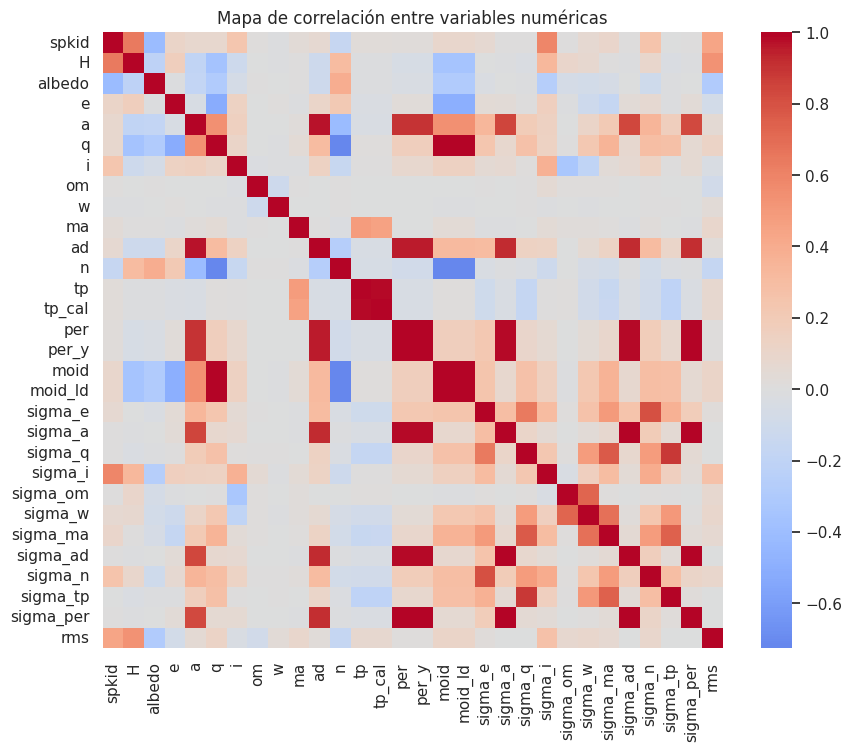

In [8]:
# --- Correlación entre variables numéricas ---
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0)
plt.title("Mapa de correlación entre variables numéricas")
plt.show()

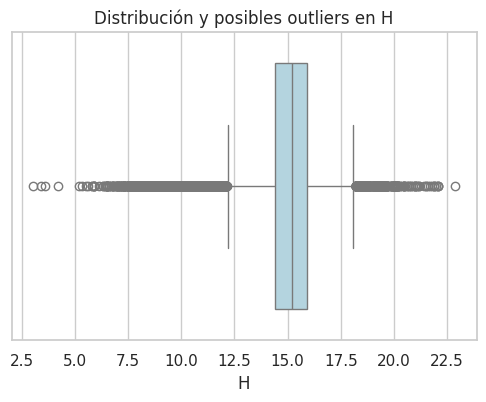

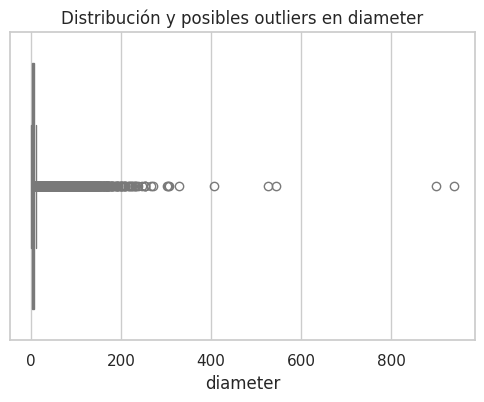

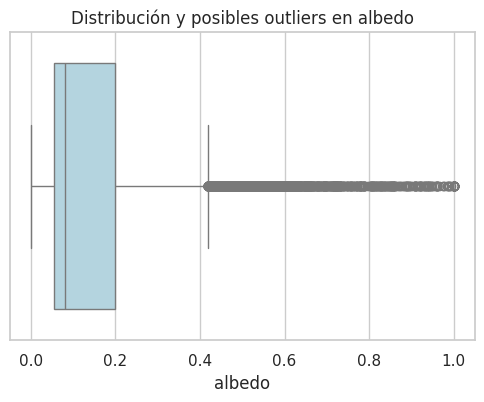

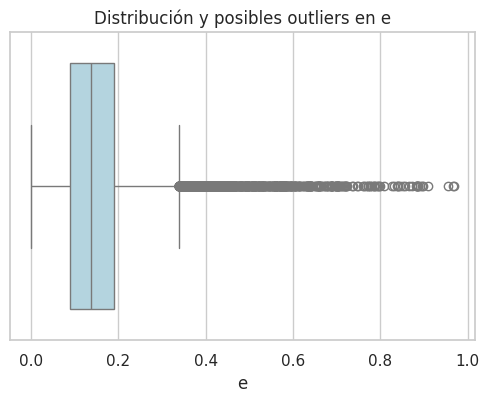

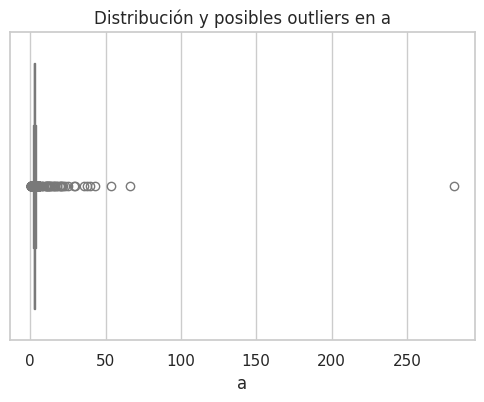

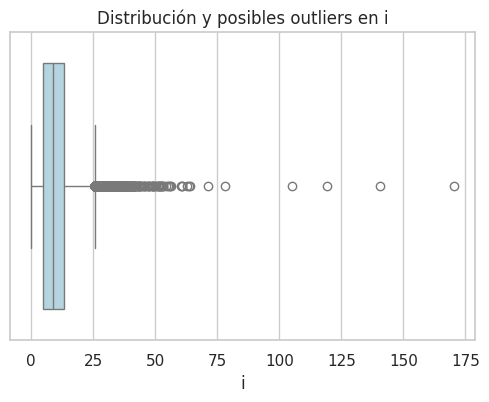

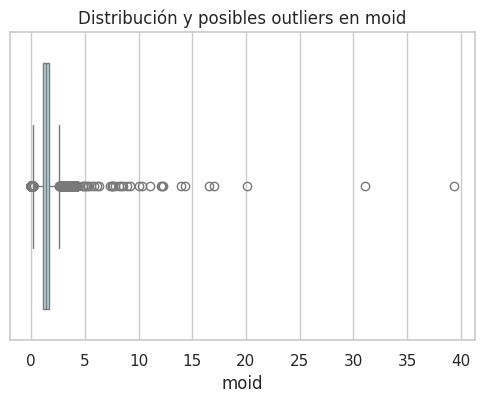

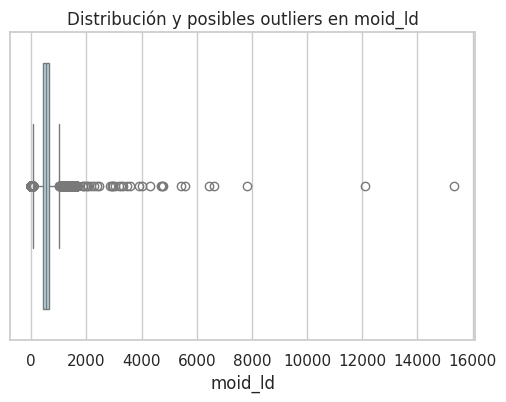

In [9]:
# --- Boxplots para detectar outliers ---
key_vars = ['H', 'diameter', 'albedo', 'e', 'a', 'i', 'moid', 'moid_ld']
for var in key_vars:
    if var in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[var], color='lightblue')
        plt.title(f"Distribución y posibles outliers en {var}")
        plt.show()

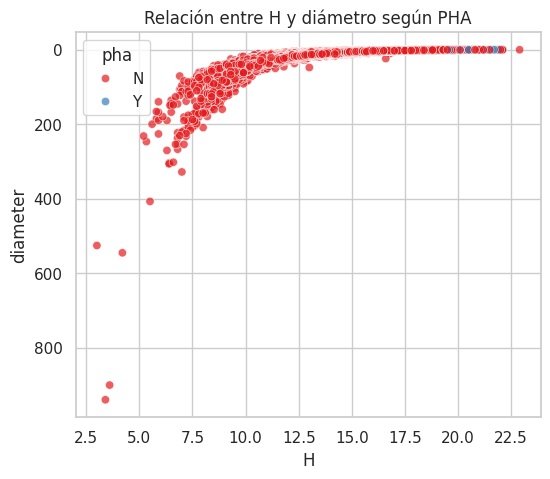

In [10]:
# --- Relaciones más relevantes ---
if all(col in df.columns for col in ['H', 'diameter', 'pha']):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x='H', y='diameter', hue='pha', data=df, palette='Set1', alpha=0.7)
    plt.title("Relación entre H y diámetro según PHA")
    plt.show()

## INFORME DE ANÁLISIS EXPLORATORIO DE DATOS (EDA)



Se comenzó con la carga del dataset Asteroid_Dataset.csv y una verificación general de su estructura. El conjunto de datos posee X filas y Y columnas, con variables tanto numéricas como categóricas. La variable objetivo identificada fue pha, que indica si un asteroide es potencialmente peligroso (Y) o no (N).

Para asegurar la correcta detección de valores faltantes, se reemplazaron expresiones como "?", "NaN", "NULL" o espacios vacíos por valores nulos reales (NaN). Luego se verificó la cantidad de datos faltantes por columna, observándose que la mayoría de las variables presentan una baja proporción de valores ausentes.

Se realizó un análisis visual con gráficos que permitieron observar la distribución de las variables numéricas y la proporción de las clases en la variable objetivo. El gráfico de barras mostró un desbalance notable en la variable pha, predominando los asteroides no peligrosos.

A continuación, se representaron histogramas para todas las variables numéricas, donde se evidenció una alta variabilidad en las escalas y la presencia de distribuciones sesgadas en algunas variables. El mapa de calor de correlación permitió identificar relaciones relevantes entre las variables, destacando una correlación negativa entre la magnitud absoluta (H) y el diámetro (diameter).

Por último, se realizaron boxplots para detectar posibles outliers en variables clave (H, diameter, albedo, e, a, i, moid, moid_ld), y un gráfico de dispersión entre H y diameter según pha, donde se observó que los asteroides potencialmente peligrosos suelen tener mayores diámetros y menor magnitud absoluta.


#Modelos

## Preprocesamiento

In [11]:
# Verificamos valores únicos en la columna 'pha' antes de mapear
print("Valores únicos originales en 'pha':", df['pha'].unique())

# Normalizamos a mayúsculas para evitar errores de formato
df['pha'] = df['pha'].astype(str).str.upper().str.strip()

# Creamos el mapeo flexible
mapa_pha = {
    'Y': 1, 'YES': 1, 'TRUE': 1, 'T': 1, '1': 1,
    'N': 0, 'NO': 0, 'FALSE': 0, 'F': 0, '0': 0
}

# Aplicamos el mapeo y mostramos qué valores no fueron reconocidos
df['pha'] = df['pha'].map(mapa_pha)
print("Valores no reconocidos (NaN):", df['pha'].isna().sum())

# Eliminamos solo filas con 'pha' vacía (no todo el DataFrame)
df = df.dropna(subset=['pha'])

# Eliminamos columnas irrelevantes si existen
cols_drop = ['name', 'pdes', 'class', 'prefix', 'neo', 'orbit_id']
df = df.drop(columns=[c for c in cols_drop if c in df.columns], errors='ignore')

# Ahora mostramos el tamaño final del DataFrame
print(f"Tamaño del DataFrame después de limpieza: {df.shape}")

# Definimos X e y
X = df.drop('pha', axis=1)
y = df['pha']

print(y.value_counts())


Valores únicos originales en 'pha': ['N' 'Y']
Valores no reconocidos (NaN): 0
Tamaño del DataFrame después de limpieza: (126131, 34)
pha
0    125975
1       156
Name: count, dtype: int64


In [12]:
# DIVISIÓN DE DATOS

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

# Eliminamos posibles columnas no numéricas
cols_obj = X_train.select_dtypes(include='object').columns
if len(cols_obj) > 0:
    print("\nColumnas no numéricas eliminadas:", list(cols_obj))
    X_train = X_train.drop(columns=cols_obj)
    X_test = X_test.drop(columns=cols_obj)


Tamaño del conjunto de entrenamiento: (88291, 33)
Tamaño del conjunto de prueba: (37840, 33)

Columnas no numéricas eliminadas: ['full_name', 'diameter', 'diameter_sigma']


In [13]:
# ESCALADO DE VARIABLES

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:

print("\nDistribución original del conjunto de entrenamiento:")
print(Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribución después de aplicar SMOTE:")
print(Counter(y_train_res))




Distribución original del conjunto de entrenamiento:
Counter({0: 88182, 1: 109})

Distribución después de aplicar SMOTE:
Counter({0: 88182, 1: 88182})


/tmp/ipython-input-253825587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='mako')
/tmp/ipython-input-253825587.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='mako')


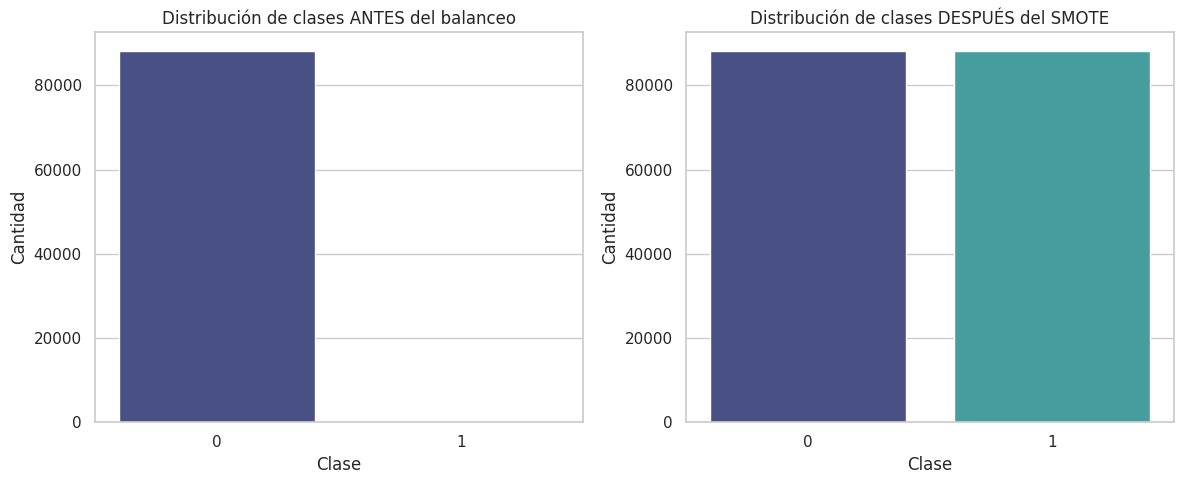

In [15]:
# Visualización del desbalanceo antes y después del SMOTE
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x=y_train, palette='mako')
plt.title('Distribución de clases ANTES del balanceo')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.subplot(1,2,2)
sns.countplot(x=y_train_res, palette='mako')
plt.title('Distribución de clases DESPUÉS del SMOTE')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Modelo KNN

k= 1 → Accuracy=0.9980 | F1 (clase 1)=0.3934
k= 2 → Accuracy=0.9980 | F1 (clase 1)=0.3934
k= 3 → Accuracy=0.9979 | F1 (clase 1)=0.4937
k= 4 → Accuracy=0.9979 | F1 (clase 1)=0.4937
k= 5 → Accuracy=0.9978 | F1 (clase 1)=0.5029
k= 6 → Accuracy=0.9978 | F1 (clase 1)=0.5029


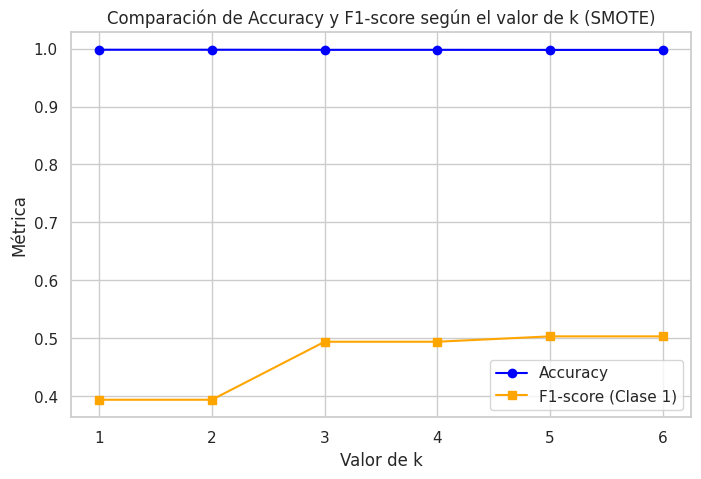


✅ Mejor k según F1 de la clase 1: 5

🔹 Evaluación del modelo KNN (Datos escalados y balanceados con SMOTE)
Accuracy: 0.9978

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9999    0.9979    0.9989     37793
           1     0.3468    0.9149    0.5029        47

    accuracy                         0.9978     37840
   macro avg     0.6733    0.9564    0.7509     37840
weighted avg     0.9991    0.9978    0.9983     37840



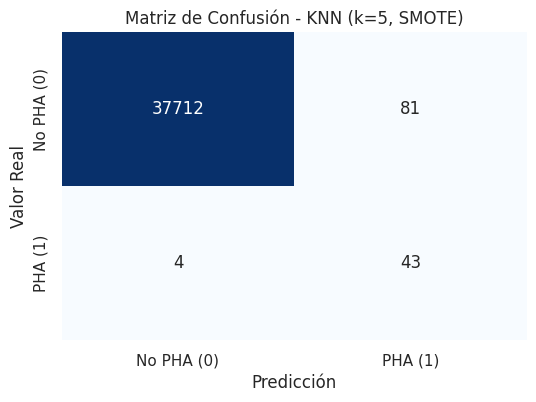

In [16]:
# Rango de valores de k a probar
k_values = range(1, 7)
accuracies = []
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_res, y_train_res)
    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    accuracies.append(acc)
    f1_scores.append(f1)

    print(f"k={k:2d} → Accuracy={acc:.4f} | F1 (clase 1)={f1:.4f}")

#  Gráfico comparativo
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o', label='Accuracy', color='blue')
plt.plot(k_values, f1_scores, marker='s', label='F1-score (Clase 1)', color='orange')
plt.title('Comparación de Accuracy y F1-score según el valor de k (SMOTE)')
plt.xlabel('Valor de k')
plt.ylabel('Métrica')
plt.legend()
plt.grid(True)
plt.show()

#Selección del mejor k según F1-score
best_k = k_values[f1_scores.index(max(f1_scores))]
print(f"\n Mejor k según F1 de la clase 1: {best_k}")

# Entrenamiento final con el mejor k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_res, y_train_res)
y_pred_best = knn_best.predict(X_test_scaled)

#  Evaluación final
print("\n Evaluación del modelo KNN (Datos escalados y balanceados con SMOTE)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_best, digits=4))

#  Matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No PHA (0)', 'PHA (1)'],
            yticklabels=['No PHA (0)', 'PHA (1)'])
plt.title(f'Matriz de Confusión - KNN (k={best_k}, SMOTE)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Al buscar el mejor valor de k mediante un ciclo for, el resultado fue k=1, ya que presentaba la mayor accuracy. Sin embargo, debido al desbalance de clases, esta métrica no refleja el verdadero rendimiento del modelo sobre la clase minoritaria (PHA). Por eso, se utilizó el F1-score de la clase 1 como criterio más adecuado para seleccionar el mejor k, priorizando el equilibrio entre precisión y recall.

##Arbol de desición


🔹 Evaluación del modelo Árbol de Decisión (Datos escalados y balanceados con SMOTE)
Accuracy: 1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     37793
           1     1.0000    0.9787    0.9892        47

    accuracy                         1.0000     37840
   macro avg     1.0000    0.9894    0.9946     37840
weighted avg     1.0000    1.0000    1.0000     37840



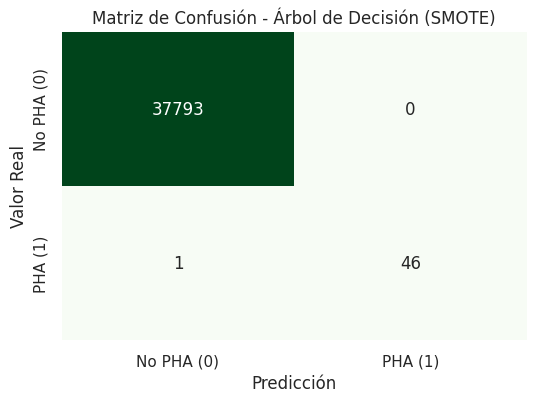

In [17]:

# Árbol de Decisión con datos escalados y balanceados (SMOTE)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=None)
tree_model.fit(X_train_res, y_train_res)

y_pred_tree = tree_model.predict(X_test_scaled)

print("\n Evaluación del modelo Árbol de Decisión (Datos escalados y balanceados con SMOTE)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_tree, digits=4))

cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No PHA (0)', 'PHA (1)'],
            yticklabels=['No PHA (0)', 'PHA (1)'])
plt.title('Matriz de Confusión - Árbol de Decisión (SMOTE)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()


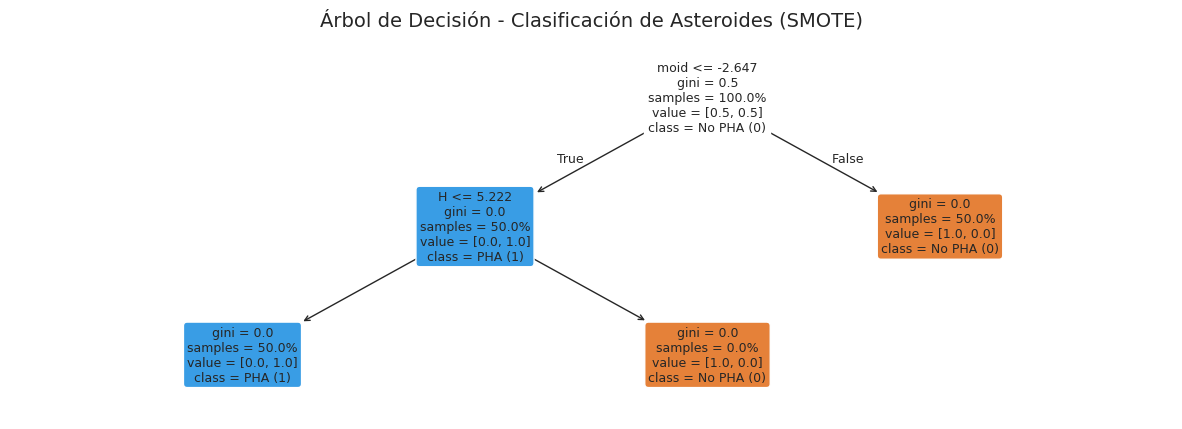

In [21]:
# Visualización del Árbol de Decisión
plt.figure(figsize=(15, 5))
plot_tree(
    tree_model,
    filled=True,
    feature_names=X_train.columns,
    class_names=['No PHA (0)', 'PHA (1)'],
    rounded=True,
    proportion=True,
    fontsize=9,
    max_depth=3
)
plt.title("Árbol de Decisión - Clasificación de Asteroides (SMOTE)", fontsize=14)
plt.show()
